# [실습 9-1] 퍼셉트론 밑바닥 구현 — XOR 실패와 2층 극복

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | **전반(셀 1~3)** 9.2 말미 / **후반(셀 4~5)** 9.4 말미 — 분할 배치 |
| 선수 실습 | [실습 7-1] (시각화 유틸) |
| 준비 | 부록 B.1·B.3 참고 |

NumPy만으로 퍼셉트론을 만들어 AND·OR에 성공시키고 XOR에서
실패하는 것까지 확인한 뒤(전반), 역전파를 배우고 돌아와
2층 신경망으로 벽을 넘는다(후반) — Before/After의 완성.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/<저장소>/ai-intro-labs.git
# %cd ai-intro-labs/notebooks
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch09/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__)

Python 3.12.6
NumPy 2.4.6


## 전반 — 단층의 벽을 확인한다 (본문 9.2 말미)\n\n### [셀 1] 퍼셉트론 구현 📖

In [2]:
import numpy as np

rng = np.random.default_rng(seed=1)

def step(z):
    """계단 활성화: 0을 넘으면 1, 아니면 0."""
    return (z > 0).astype(int)

class Perceptron:
    """인공 뉴런 1개 + 퍼셉트론 학습 규칙."""
    def __init__(self, lr=0.1):
        self.w = rng.normal(0, 0.1, size=2)
        self.b = 0.0
        self.lr = lr

    def predict(self, X):
        return step(X @ self.w + self.b)   # 가중합->활성화

    def fit(self, X, y, epochs=20):
        for _ in range(epochs):
            for xi, ti in zip(X, y):
                err = ti - self.predict(xi)
                self.w += self.lr * err * xi
                self.b += self.lr * err
        return self

**핵심 포인트**
- `predict()`의 한 줄이 9.1.1의 두 단계(가중합 → 활성화) 전부다.
- 학습 규칙 세 줄이 로젠블랫의 규칙 그대로다 — 오차(err)가 0이면 다이얼을 건드리지 않고, 틀린 만큼·입력이 켜진 만큼 돌린다.
- 시드를 고정(`seed=1`)해 누가 실행해도 같은 결과가 재현된다.

### [셀 2] AND와 OR — 직선 하나로 충분한 문제 📖

AND: 정확도 100%
OR: 정확도 100%


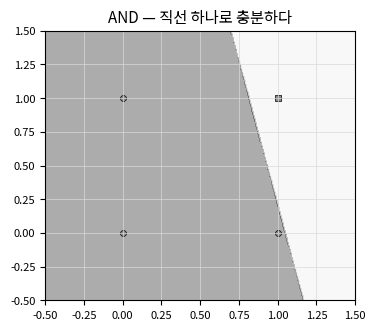

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])

for name, y in (("AND", y_and), ("OR", y_or)):
    p = Perceptron().fit(X, y)
    acc = (p.predict(X) == y).mean()
    print(f"{name}: 정확도 {acc:.0%}")

viz.plot_decision_boundary(
    Perceptron().fit(X, y_and), X, y_and,
    title="AND — 직선 하나로 충분하다")
plt.show()

**핵심 포인트**
- 진리표 네 점이 학습 데이터의 전부다 — 외부 데이터 없이 개념만 확인한다.
- 출력 그림에서 결정 경계가 직선 하나임을 확인하자. 퍼셉트론이 가진 표현력의 전부다.

기대 출력: `AND: 정확도 100%` / `OR: 정확도 100%`

### [셀 3] XOR — 벽에 부딪히다 📖

XOR: 정확도 50% <- 에폭을 늘려도 그대로


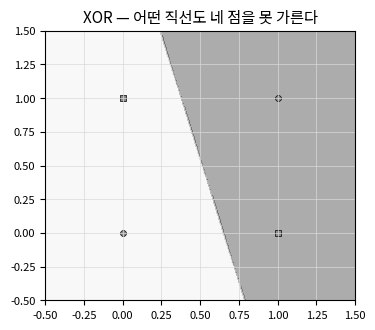

In [4]:
y_xor = np.array([0, 1, 1, 0])

p = Perceptron().fit(X, y_xor, epochs=200)
acc = (p.predict(X) == y_xor).mean()
print(f"XOR: 정확도 {acc:.0%} <- 에폭을 늘려도 그대로")

viz.plot_decision_boundary(
    p, X, y_xor,
    title="XOR — 어떤 직선도 네 점을 못 가른다")
plt.show()

**핵심 포인트**
- 에폭을 20에서 200으로 열 배 늘려도 정확도는 50%(4점 중 2점) — 동전 던지기와 같다. 학습이 부족한 것이 아니라 **모델의 표현력이 부족한 것**이다 — 9.1.2의 기하학적 한계가 수치로 확인된다.
- 그림에서 직선이 어디에 놓여도 대각선으로 엇갈린 네 점을 가를 수 없음을 눈으로 확인하자.

실패 시 대처: 그림의 한글이 □로 보이면 [준비] 셀 재실행 후 런타임 재시작. AND/OR가 100%가 안 나오면 시드 고정 여부와 에폭 수(기본 20) 확인.

---
## 후반 — 2층 신경망으로 XOR 벽 넘기 (본문 9.4 말미)

> 여기부터는 본문 9.4(역전파)를 읽은 뒤 진행한다.

### [셀 4] 2층 신경망 구현 — 역전파 포함 📖

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

class TwoLayerNet:      # 입력 2 - 은닉 2 - 출력 1
    def __init__(self, lr=0.5):
        self.V = rng.normal(0, 1.0, size=(2, 2))
        self.w = rng.normal(0, 1.0, size=2)
        self.c, self.b, self.lr = np.zeros(2), 0.0, lr
    def forward(self, X):
        self.H = sigmoid(X @ self.V + self.c)
        return sigmoid(self.H @ self.w + self.b)
    def fit(self, X, y, epochs=4000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)            # 순전파
            d_out = (out - y) * out * (1 - out)
            d_H = (np.outer(d_out, self.w)
                   * self.H * (1 - self.H))  # 역전파
            self.w -= self.lr * self.H.T @ d_out
            self.b -= self.lr * d_out.sum()
            self.V -= self.lr * X.T @ d_H    # 갱신
            self.c -= self.lr * d_H.sum(axis=0)
            losses.append(((out - y) ** 2).mean())
        return losses

**핵심 포인트**
- `fit()` 안의 넉 줄 블록이 9.4.2의 3~4단계를 행렬로 압축한 것이다 — `d_out`이 출력의 오차 신호, `d_H`가 은닉층으로 흘려보낸 오차 신호에 활성화 미분을 곱한 것(시그모이드의 미분은 out×(1−out)이다).
- XOR의 매끄러운 학습을 위해 여기서는 시그모이드를 썼다. 손계산(ReLU·항등)과 활성화만 다를 뿐 오차를 거꾸로 흘리는 구조는 동일하다.
- `np.clip`은 지수 함수의 오버플로 경고를 막는 실전 습관이다.

### [셀 5] XOR 재도전 📖

XOR 재도전: 정확도 100%
손실 0.265 -> 0.001


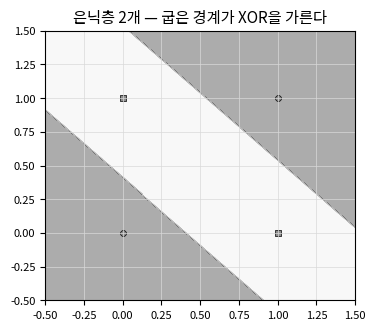

In [6]:
net = TwoLayerNet()
losses = net.fit(X, y_xor)
pred = (net.forward(X) > 0.5).astype(int)
acc = (pred == y_xor).mean()
print(f"XOR 재도전: 정확도 {acc:.0%}")
print(f"손실 {losses[0]:.3f} -> {losses[-1]:.3f}")

viz.plot_decision_boundary(
    net, X, y_xor,
    title="은닉층 2개 — 굽은 경계가 XOR을 가른다")
plt.show()

**핵심 포인트**
- 같은 네 점, 달라진 것은 은닉층 하나뿐 — 동전 던지기(50%, [셀 3])가 100%로 바뀐다. 결정 경계는 더 이상 직선이 아니라 굽은 띠다.
- [보조 1]은 9.4.2 손계산과 코드의 대조, [보조 2]는 은닉 뉴런별 경계 분해다.

실패 시 대처: 간혹 손실이 0.25 부근에서 오래 정체할 수 있다 — 비볼록 지형의 정체 지점(9.3.2)을 실물로 만난 것이다. 지면 수치는 시드 고정으로 재현되며, 시드를 바꿔 정체를 일부러 관찰해 보는 것도 좋은 실험이다. `RuntimeWarning: overflow`가 보이면 [셀 4]의 `np.clip` 줄 확인.

### [보조 1] 9.4.2 손계산 재현 — 손과 코드의 대조

In [7]:
# 본문 9.4.2와 동일한 가중치·입력 (의도된 일치)
x, t, eta = np.array([1.0, 1.0]), 3.0, 0.1
V = np.array([[0.5, 1.0],       # (v11, v12)
              [1.0, -0.5]])     # (v21, v22)
c = np.array([-0.5, 0.0])
w = np.array([2.0, 1.0])
b = -0.5

z = V @ x + c
h = np.maximum(z, 0)            # ReLU
y = w @ h + b
print(f"순전파: h={h}, y={y:.1f}, "
      f"L={0.5 * (y - t) ** 2:.2f}")

d_y = y - t                     # 출력 오차 신호
g_w, g_b = d_y * h, d_y
d_h = d_y * w * (z > 0)         # 은닉 오차 신호
g_V, g_c = np.outer(d_h, x), d_h
print("기울기 w:", g_w, "b:", g_b)
print("기울기 V:", g_V.ravel(), "c:", g_c)

w_n, b_n = w - eta * g_w, b - eta * g_b
V_n, c_n = V - eta * g_V, c - eta * g_c
h_n = np.maximum(V_n @ x + c_n, 0)
y_n = w_n @ h_n + b_n
print(f"갱신 후 재순전파: y={y_n:.1f}, "
      f"L={0.5 * (y_n - t) ** 2:.2f}")

순전파: h=[1.  0.5], y=2.0, L=0.50
기울기 w: [-1.  -0.5] b: -1.0
기울기 V: [-2. -2. -1. -1.] c: [-2. -1.]
갱신 후 재순전파: y=3.8, L=0.32


본문 [표 9-2]의 기울기 9종(w: −1.0, −0.5 / b: −1.0 / V: −2.0, −2.0, −1.0, −1.0 / c: −2.0, −1.0)과 갱신 후 y=3.8, L=0.32가 코드로 그대로 재현된다 — 손으로 계산한 것과 기계가 계산한 것이 같은 계산임을 확인하는 셀이다.

### [보조 2] 은닉 뉴런 해부 — 직선 둘이 굽은 경계를 만든다

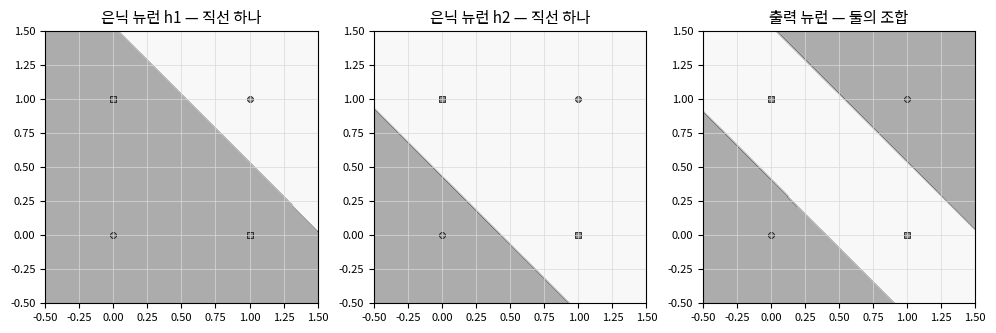

In [8]:
class HiddenUnit:
    """학습된 은닉 뉴런 i의 단독 경계를 보기 위한 래퍼."""
    def __init__(self, net, i):
        self.net, self.i = net, i
    def predict(self, A):
        H = sigmoid(A @ self.net.V + self.net.c)
        return (H[:, self.i] > 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for i in (0, 1):
    viz.plot_decision_boundary(
        HiddenUnit(net, i), X, y_xor, ax=axes[i],
        title=f"은닉 뉴런 h{i + 1} — 직선 하나")
viz.plot_decision_boundary(
    net, X, y_xor, ax=axes[2],
    title="출력 뉴런 — 둘의 조합")
plt.tight_layout()
plt.show()

각 은닉 뉴런은 여전히 **직선 하나**만 긋는다 — 그러나 출력 뉴런이 두 직선을 조합하면 굽은 경계가 된다(9.2.1). 층을 쌓는다는 것의 기하학적 의미가 이 세 그림에 있다.

### [심화 1] 정체 지점 관찰 (연습문제 심화 연계)

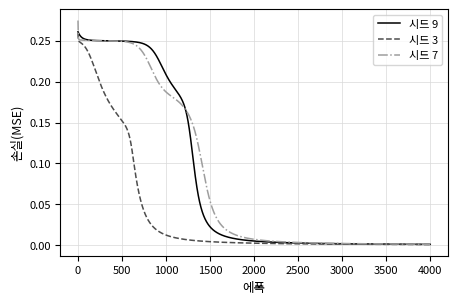

In [9]:
# TODO: 시드를 바꿔 가며 손실 곡선을 겹쳐 그려 보자.
#       어떤 시드에서 0.25 부근 정체(비볼록 지형의
#       안장·평지, 9.3.2)가 나타나는가?
fig, ax = plt.subplots(figsize=(5, 3.2))
for seed in (9, 3, 7):
    rng_v = np.random.default_rng(seed)
    net_v = TwoLayerNet.__new__(TwoLayerNet)
    net_v.V = rng_v.normal(0, 1.0, size=(2, 2))
    net_v.w = rng_v.normal(0, 1.0, size=2)
    net_v.c, net_v.b, net_v.lr = np.zeros(2), 0.0, 0.5
    ls = net_v.fit(X, y_xor)
    ax.plot(ls, lw=1.1, label=f"시드 {seed}")
ax.set_xlabel("에폭")
ax.set_ylabel("손실(MSE)")
ax.legend()
plt.show()

---
## 마무리

- 퍼셉트론의 표현력은 직선 하나 — XOR 앞에서 멈춘다([셀 3]). 층을 쌓고 역전파로 학습하면 굽은 경계가 열린다([셀 5]).
- 역전파는 손계산(9.4.2)과 코드([보조 1])가 **같은 계산**이다 — 신경망은 더 이상 블랙박스가 아니다.
- 은닉 뉴런 하나하나는 여전히 단순하다([보조 2]) — 조합이 표현력을 만든다.

**연습문제 연계**: [응용] 순전파·역전파 손계산 문항은 [보조 1]의 코드로 자가 검증, [심화] 학습률·수렴 거동 분석은 [심화 1]에서 수행한다.

**다음 실습**: [실습 9-2] Keras MNIST — 드롭아웃 Before/After (`lab-09-02_keras-mnist.ipynb`)